In [3]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
from dotenv import load_dotenv

In [4]:

load_dotenv()

True

In [5]:
llm1 = HuggingFaceEndpoint(repo_id="Qwen/Qwen2.5-7B-Instruct")
model = ChatHuggingFace(llm=llm1)

In [6]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [21]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

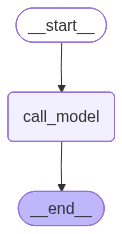

In [23]:
graph = builder.compile()
graph

In [24]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Shubham."}]})

{'messages': [HumanMessage(content='Hi! My name is Shubham.', additional_kwargs={}, response_metadata={}, id='175d99c2-0b29-4fc9-b3a7-6cfe9c3d3351'),
  AIMessage(content='Hello Shubham! Nice to meet you. How can I assist you today? Feel free to ask me any questions or let me know if you need any information on a particular topic.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 38, 'total_tokens': 77}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6727-ab87-7050-bf9b-cc6663973f1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 39, 'total_tokens': 77})]}

In [10]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9b6fc2a7-9710-475e-936e-c862d8b4872e'),
  AIMessage(content="You didn't provide your name in your message. In our conversation, you can tell me your name if you'd like me to use it!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 34, 'total_tokens': 64}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6724-81c6-7631-b0f7-dfd155f1b744-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 30, 'total_tokens': 64})]}

In [27]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [28]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [29]:

graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is shubham."}]}, config2)

{'messages': [HumanMessage(content='Hi! My name is shubham.', additional_kwargs={}, response_metadata={}, id='5884c406-6364-44ba-84d7-7430071a42b5'),
  AIMessage(content="Hello Shubham! Nice to meet you. How can I assist you today? Is there anything specific you'd like to talk about or any questions you have?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 38, 'total_tokens': 72}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6728-ff70-7823-8dd2-a5758b23ddba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 34, 'total_tokens': 72})]}

In [30]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='Hi! My name is shubham.', additional_kwargs={}, response_metadata={}, id='5884c406-6364-44ba-84d7-7430071a42b5'),
  AIMessage(content="Hello Shubham! Nice to meet you. How can I assist you today? Is there anything specific you'd like to talk about or any questions you have?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 38, 'total_tokens': 72}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6728-ff70-7823-8dd2-a5758b23ddba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 34, 'total_tokens': 72}),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='abd24445-8f24-4218-9cef-7dea84eb2975'),
  AIMessage(content='Your name is Shubham.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 86, '

In [31]:
snap = graph.get_state(config2)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is shubham.
- AIMessage : Hello Shubham! Nice to meet you. How can I assist you today? Is there anything specific you'd like to talk about or any questions you have?
- HumanMessage : What is my name?
- AIMessage : Your name is Shubham.
